# CV-QEC: Numerical Simulations

This notebook reproduces the key figures from:

**"Discrete-variable assisted error correction of continuous-variable quantum information"**  
Negin Razian, En-Jui Chang, and Hoi-Kwan Lau

## Structure
1. Displacement error channel — Equation (1)
2. Filter function after qubit measurement — Equation (7)  
3. Optimal α and variance suppression — Figure 2
4. Variance vs qudit dimension d — Figure 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

## 1. Displacement Error Channel

The random displacement error transforms a CV state $\hat{\rho}_{cv}$ as:

$$\mathcal{E}(\hat{\rho}_{cv}) = \int P(\beta) \hat{D}(\beta) \hat{\rho}_{cv} \hat{D}^\dagger(\beta) d^2\beta$$

where the displacement distribution is Gaussian:

$$P(\beta) = G(\beta_q, \sigma) G(\beta_p, \sigma), \quad G(x,\sigma) \equiv \frac{e^{-x^2/\sigma^2}}{\sqrt{\pi}\sigma}$$

We characterize the noise by $\sigma$ — the standard deviation of the displacement.

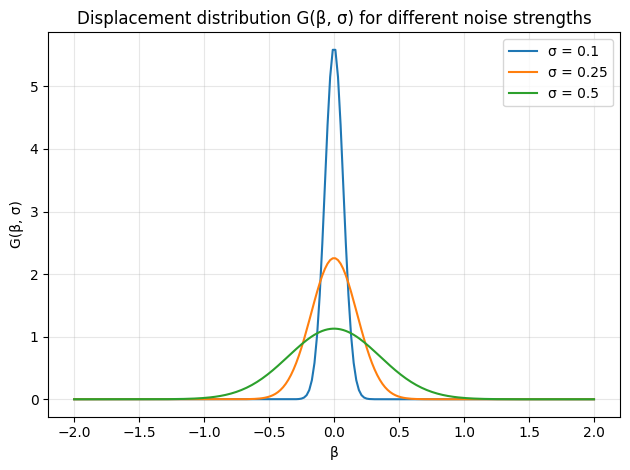

In [5]:
# Disapacement distribution from Equation (2)
def G(x, sigma):
    return np.exp(-x**2 / sigma**2)/(np.sqrt(np.pi) * sigma)

def P(beta_q, beta_p, sigma):
    return G(beta_q, sigma) * G(beta_p, sigma)

# Plot for different sigma values 
beta = np.linspace(-2 ,2, 200)
sigmas = [0.1, 0.25, 0.5]

plt.Figure(figsize=(8, 4))

for sigma in sigmas:
    plt.plot(beta, G(beta, sigma), label=f'σ = {sigma}')

plt.xlabel('β')
plt.ylabel('G(β, σ)')
plt.title('Displacement distribution G(β, σ) for different noise strengths')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Filter Function After Qubit Measurement — Equation (7)

After encoding, displacement error, and decoding, the qubit is measured 
in the $\{|\pm Y\rangle\}$ basis.

Upon outcome $|\pm Y\rangle$, the displacement distribution is modified by a filter:

$$P(\beta_p) \rightarrow G(\beta_p, \sigma)(1 \pm \sin(4\alpha\beta_p))$$

The modified distribution has mean:

$$\bar{\beta}_\pm = \pm 2\alpha\sigma^2 e^{-4\alpha^2\sigma^2}$$

The correction is to displace back by $\bar{\beta}_\pm$.

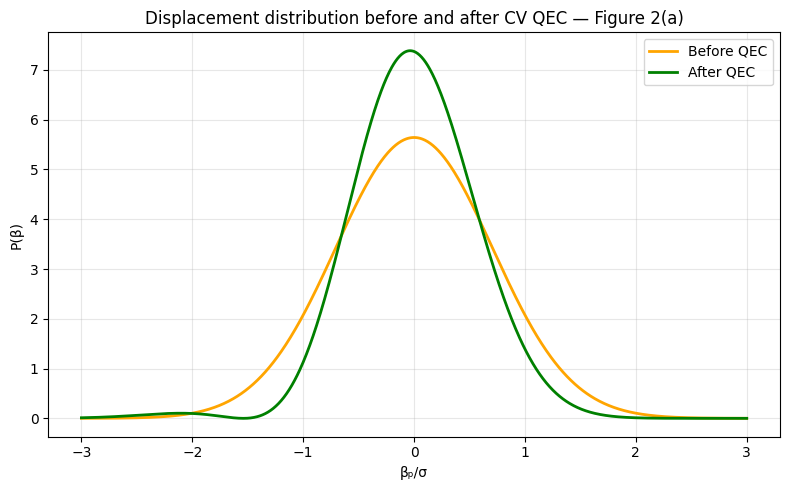

Variance before QEC: 0.005000
Variance after QEC:  0.003161
Reduction: 36.8%


In [7]:
# Filter function after qubit measurement — Figure 2(a)
def filtered_distribution(beta_p, sigma, alpha, sign=+1):
    """Modified displacement distribution after qubit measurement."""
    return G(beta_p, sigma) * (1 + sign * np.sin(4 * alpha * beta_p))

def beta_mean(sigma, alpha, sign=+1):
    """Mean of the corrected distribution — analytical formula."""
    return sign * 2 * alpha * sigma**2 * np.exp(-4 * alpha**2 * sigma**2)

# Parameters from paper
sigma = 0.1
alpha_opt = 1 / (2 * np.sqrt(2) * sigma)   # optimal alpha from paper

beta_p = np.linspace(-3*sigma, 3*sigma, 1000)

# Before QEC
P_before = G(beta_p, sigma)

# After QEC — |+Y⟩ outcome
P_after = filtered_distribution(beta_p, sigma, alpha_opt, sign=+1)
beta_bar = beta_mean(sigma, alpha_opt, sign=+1)

# Corrected distribution — shift back by beta_bar
P_corrected = filtered_distribution(beta_p + beta_bar, sigma, alpha_opt, sign=+1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(beta_p/sigma, P_before,    color='orange', label='Before QEC', linewidth=2)
plt.plot(beta_p/sigma, P_corrected, color='green',  label='After QEC', linewidth=2)
plt.xlabel('βₚ/σ')
plt.ylabel('P(β)')
plt.title('Displacement distribution before and after CV QEC — Figure 2(a)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print variance reduction
var_before = sigma**2 / 2
var_after  = (1 - 1/np.e) * sigma**2 / 2
print(f"Variance before QEC: {var_before:.6f}")
print(f"Variance after QEC:  {var_after:.6f}")
print(f"Reduction: {(1 - var_after/var_before)*100:.1f}%")

## 3. Optimal Conditional Displacement Strength — Figure 2(b)

The performance depends on the choice of $\alpha$. 
The optimal value that minimizes the corrected variance is:

$$\alpha_{opt} = \frac{1}{2\sqrt{2}\sigma}$$

We verify this numerically by computing the variance for different $\alpha$.

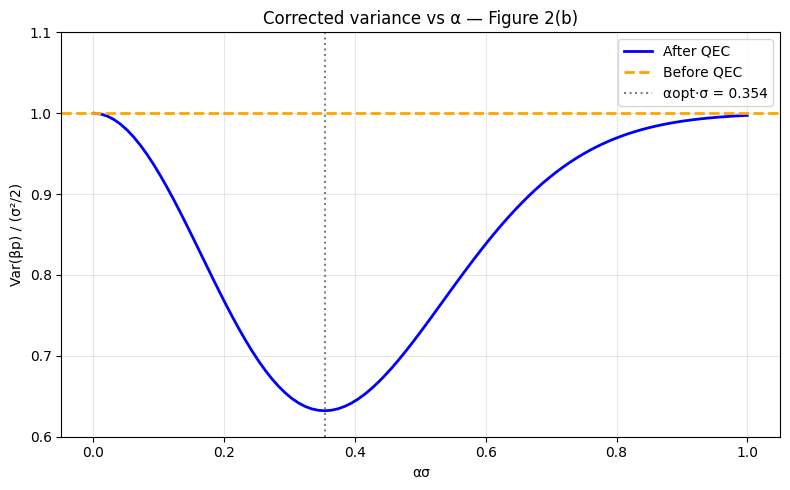

Optimal α·σ = 0.3536
Minimum variance ratio = 0.6321


In [8]:
# Variance vs alpha — Figure 2(b)
def variance_after_qec(alpha, sigma):
    """Compute corrected variance numerically."""
    beta_p = np.linspace(-6*sigma, 6*sigma, 2000)
    db = beta_p[1] - beta_p[0]
    
    # Filtered distribution for +Y outcome
    P_filt = filtered_distribution(beta_p, sigma, alpha, sign=+1)
    N_plus = np.sum(P_filt) * db   # normalisation
    
    # Mean
    beta_bar = np.sum(beta_p * P_filt) * db / N_plus
    
    # Corrected distribution
    P_corr = filtered_distribution(beta_p + beta_bar, sigma, alpha, sign=+1)
    
    # Variance
    var = np.sum(beta_p**2 * P_corr) * db / np.sum(P_corr * db)
    return var

sigma = 0.1
alphas = np.linspace(0.01, 1.0/sigma, 100)
variances = [variance_after_qec(a, sigma) / (sigma**2/2) for a in alphas]

alpha_opt = 1 / (2 * np.sqrt(2) * sigma)

plt.figure(figsize=(8, 5))
plt.plot(alphas * sigma, variances, color='blue', linewidth=2, label='After QEC')
plt.axhline(y=1.0, color='orange', linestyle='--', linewidth=2, label='Before QEC')
plt.axvline(x=alpha_opt * sigma, color='gray', linestyle=':', linewidth=1.5, label=f'αopt·σ = {alpha_opt*sigma:.3f}')
plt.xlabel('ασ')
plt.ylabel('Var(βp) / (σ²/2)')
plt.title('Corrected variance vs α — Figure 2(b)')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim([0.6, 1.1])
plt.tight_layout()
plt.show()

print(f"Optimal α·σ = {alpha_opt*sigma:.4f}")
print(f"Minimum variance ratio = {min(variances):.4f}")

## 5. Squeezing-Enhanced 2D Protocol

Squeezing redistributes noise between quadratures:

$$\beta_q \rightarrow \beta_q e^{2\zeta}, \quad \beta_p \rightarrow \beta_p e^{-2\zeta}$$

The optimal squeezing parameter is:

$$\zeta = \frac{1}{8}\ln(1 - e^{-1})$$

which gives total variance reduction of **20.5%**.

The corrected variances are:

$$\text{Var}(\beta_q') = \frac{(\sigma e^{2\zeta})^2}{2}, \quad \text{Var}(\beta_p') = \frac{(\sigma e^{-2\zeta})^2}{2}\left(1 - \frac{1}{e}\right)$$

Optimal ζ = -0.057334
Squeezing in dB = 0.996 dB


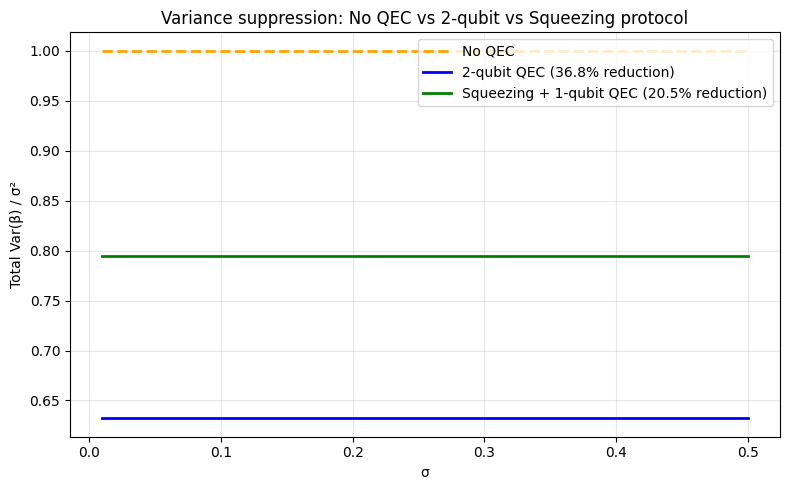


Variance reduction — 2-qubit QEC:    36.8%
Variance reduction — Squeezing QEC:  20.5%


In [9]:
# Squeezing-enhanced 2D protocol

# Optimal squeezing parameter
zeta_opt = (1/8) * np.log(1 - np.exp(-1))
print(f"Optimal ζ = {zeta_opt:.6f}")
print(f"Squeezing in dB = {-20*np.log10(np.exp(2*zeta_opt)):.3f} dB")

def total_variance_squeezed(sigma, zeta):
    """Total variance after squeezing + 1D QEC on p-quadrature."""
    # Squeezed noise strengths
    sigma_q = sigma * np.exp(2*zeta)    # amplified
    sigma_p = sigma * np.exp(-2*zeta)   # squeezed
    
    # q-quadrature: only squeezed, no QEC
    var_q = sigma_q**2 / 2
    
    # p-quadrature: squeezed + 1D QEC with optimal alpha
    var_p = (sigma_p**2 / 2) * (1 - 1/np.e)
    
    return var_q + var_p

# Compare three cases vs sigma
sigmas = np.linspace(0.01, 0.5, 100)

var_no_qec      = sigmas**2              # no QEC
var_1d_qec      = sigmas**2 * (1 - 1/np.e)   # 1D QEC both quadratures
var_squeezed    = np.array([total_variance_squeezed(s, zeta_opt) for s in sigmas])

# Normalize by sigma^2
plt.figure(figsize=(8, 5))
plt.plot(sigmas, var_no_qec   / sigmas**2, 
         color='orange', linestyle='--', linewidth=2, label='No QEC')
plt.plot(sigmas, var_1d_qec   / sigmas**2, 
         color='blue',   linewidth=2, label='2-qubit QEC (36.8% reduction)')
plt.plot(sigmas, var_squeezed / sigmas**2, 
         color='green',  linewidth=2, label='Squeezing + 1-qubit QEC (20.5% reduction)')

plt.xlabel('σ')
plt.ylabel('Total Var(β) / σ²')
plt.title('Variance suppression: No QEC vs 2-qubit vs Squeezing protocol')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print key numbers
print(f"\nVariance reduction — 2-qubit QEC:    {(1 - (1-1/np.e))*100:.1f}%")
print(f"Variance reduction — Squeezing QEC:  {(1 - np.sqrt(1-1/np.e))*100:.1f}%")

## 6. 2D Corrected Displacement Distribution

The full corrected 2D distribution after squeezing + 1D QEC:

$$P_{corr}(\beta_q, \beta_p) = G(\beta_q, \sigma e^{2\zeta}) \cdot 
G(\beta_p + \bar{\beta}_\pm', \sigma e^{-2\zeta})
\left(1 \pm \sin\left(4\alpha(\beta_p + \bar{\beta}_\pm')\right)\right)$$

- **q-quadrature**: squeezed Gaussian — slightly wider
- **p-quadrature**: filtered and corrected — significantly narrower

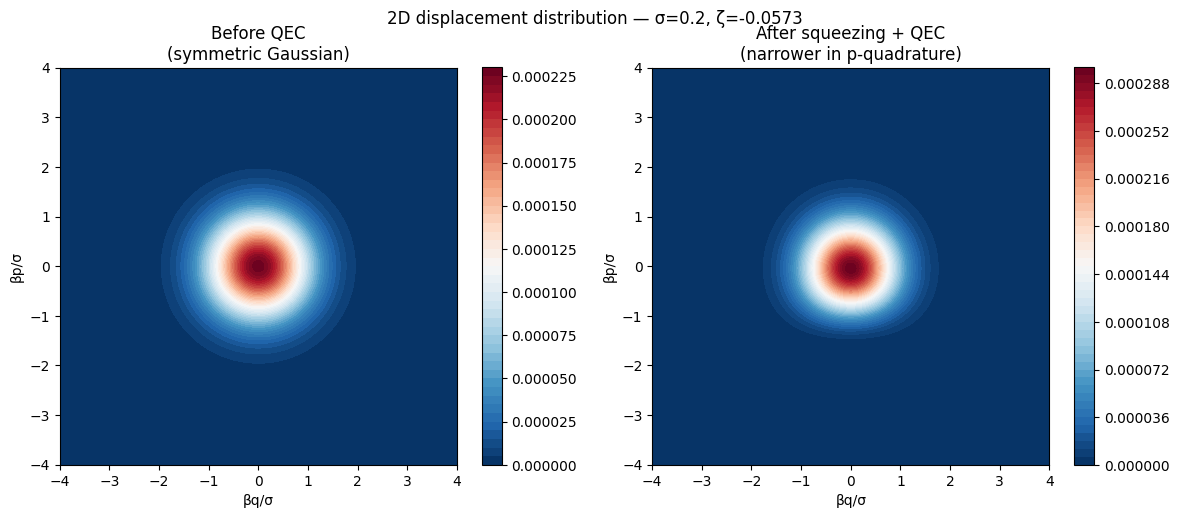

Before QEC — Var(βq)=0.020000, Var(βp)=0.020000, Total=0.040000
After  QEC — Var(βq)=0.015901,  Var(βp)=0.015896,  Total=0.031797
Total variance reduction: 20.5%


In [10]:
# 2D corrected displacement distribution

sigma = 0.2
zeta  = zeta_opt

# Squeezed noise strengths
sigma_q = sigma * np.exp(2*zeta)
sigma_p = sigma * np.exp(-2*zeta)

# Optimal alpha in squeezed frame
alpha_opt_sq = 1 / (np.sqrt(8) * sigma_p)

# Mean correction
beta_bar = 2 * alpha_opt_sq * sigma_p**2 * np.exp(-4 * alpha_opt_sq**2 * sigma_p**2)

# Grid
bq = np.linspace(-4*sigma, 4*sigma, 300)
bp = np.linspace(-4*sigma, 4*sigma, 300)
BQ, BP = np.meshgrid(bq, bp)

# Before QEC — symmetric Gaussian
P_before = G(BQ, sigma) * G(BP, sigma)

# After QEC — filtered and corrected
P_after = (G(BQ, sigma_q) * 
           G(BP + beta_bar, sigma_p) * 
           (1 + np.sin(4 * alpha_opt_sq * (BP + beta_bar))))

# Normalize
P_before /= np.sum(P_before)
P_after  /= np.sum(P_after)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
cont0 = axes[0].contourf(BQ/sigma, BP/sigma, P_before, levels=50, cmap='RdBu_r')
plt.colorbar(cont0, ax=axes[0])
axes[0].set_title('Before QEC\n(symmetric Gaussian)')
axes[0].set_xlabel('βq/σ')
axes[0].set_ylabel('βp/σ')
axes[0].set_aspect('equal')

# After
cont1 = axes[1].contourf(BQ/sigma, BP/sigma, P_after, levels=50, cmap='RdBu_r')
plt.colorbar(cont1, ax=axes[1])
axes[1].set_title('After squeezing + QEC\n(narrower in p-quadrature)')
axes[1].set_xlabel('βq/σ')
axes[1].set_ylabel('βp/σ')
axes[1].set_aspect('equal')

plt.suptitle(f'2D displacement distribution — σ={sigma}, ζ={zeta:.4f}')
plt.tight_layout()
plt.show()

# Print variances
var_q_before = np.sum(BQ**2 * P_before)
var_p_before = np.sum(BP**2 * P_before)
var_q_after  = np.sum(BQ**2 * P_after)
var_p_after  = np.sum(BP**2 * P_after)

print(f"Before QEC — Var(βq)={var_q_before:.6f}, Var(βp)={var_p_before:.6f}, Total={var_q_before+var_p_before:.6f}")
print(f"After  QEC — Var(βq)={var_q_after:.6f},  Var(βp)={var_p_after:.6f},  Total={var_q_after+var_p_after:.6f}")
print(f"Total variance reduction: {(1-(var_q_after+var_p_after)/(var_q_before+var_p_before))*100:.1f}%")

## 7. 2D Corrected Distribution — Two Ancilla Qubits

With two ancilla qubits, each quadrature is corrected independently:

$$P(\beta) \rightarrow G(\beta_q, \sigma)(1 \mp \sin(4\alpha_I\beta_q)) 
\times G(\beta_p, \sigma)(1 \pm \sin(4\alpha_R\beta_p))$$

where $\alpha_R = \alpha_I = 1/(\sqrt{8}\sigma)$ are optimal.

Each quadrature variance is reduced by $(1 - 1/e)$, giving total reduction of **36.8%**.

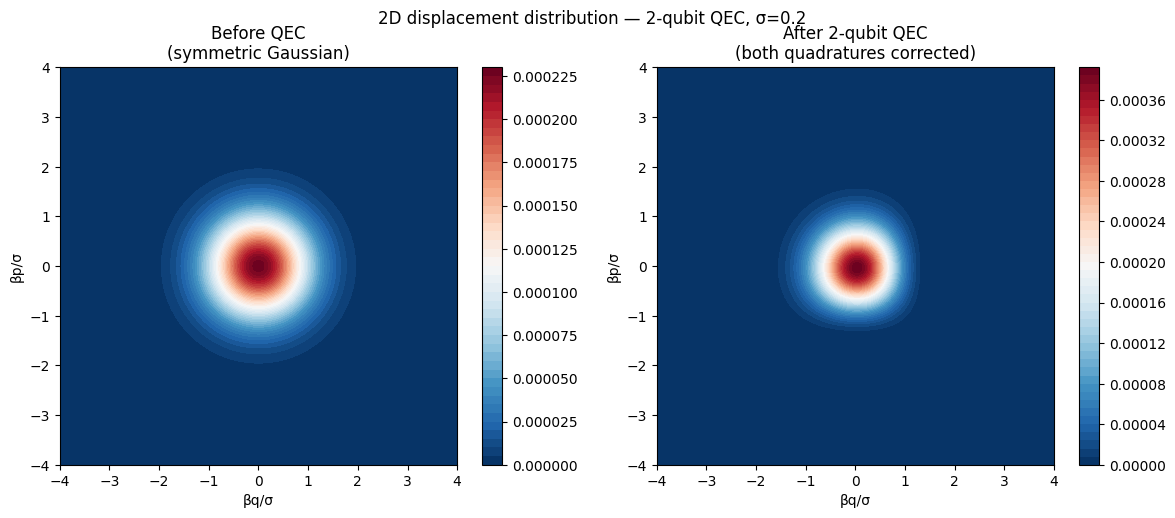

Before QEC — Var(βq)=0.020000, Var(βp)=0.020000, Total=0.040000
After  QEC — Var(βq)=0.012642,  Var(βp)=0.012642,  Total=0.025284
Total variance reduction: 36.8%


In [11]:
# 2D corrected distribution — two ancilla qubits

sigma = 0.2
alpha_R = 1 / (np.sqrt(8) * sigma)   # optimal for p-quadrature
alpha_I = 1 / (np.sqrt(8) * sigma)   # optimal for q-quadrature

# Mean corrections — note opposite signs
beta_bar_q = -2 * alpha_I * sigma**2 * np.exp(-4 * alpha_I**2 * sigma**2)
beta_bar_p = +2 * alpha_R * sigma**2 * np.exp(-4 * alpha_R**2 * sigma**2)

# Grid
bq = np.linspace(-4*sigma, 4*sigma, 300)
bp = np.linspace(-4*sigma, 4*sigma, 300)
BQ, BP = np.meshgrid(bq, bp)

# Before QEC
P_before = G(BQ, sigma) * G(BP, sigma)

# After 2-qubit QEC
P_q = G(BQ + beta_bar_q, sigma) * (1 - np.sin(4 * alpha_I * (BQ + beta_bar_q)))
P_p = G(BP + beta_bar_p, sigma) * (1 + np.sin(4 * alpha_R * (BP + beta_bar_p)))
P_after_2qubit = P_q * P_p

# Normalize
P_before        /= np.sum(P_before)
P_after_2qubit  /= np.sum(P_after_2qubit)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cont0 = axes[0].contourf(BQ/sigma, BP/sigma, P_before, levels=50, cmap='RdBu_r')
plt.colorbar(cont0, ax=axes[0])
axes[0].set_title('Before QEC\n(symmetric Gaussian)')
axes[0].set_xlabel('βq/σ')
axes[0].set_ylabel('βp/σ')
axes[0].set_aspect('equal')

cont1 = axes[1].contourf(BQ/sigma, BP/sigma, P_after_2qubit, levels=50, cmap='RdBu_r')
plt.colorbar(cont1, ax=axes[1])
axes[1].set_title('After 2-qubit QEC\n(both quadratures corrected)')
axes[1].set_xlabel('βq/σ')
axes[1].set_ylabel('βp/σ')
axes[1].set_aspect('equal')

plt.suptitle(f'2D displacement distribution — 2-qubit QEC, σ={sigma}')
plt.tight_layout()
plt.show()

# Print variances
var_q_before = np.sum(BQ**2 * P_before)
var_p_before = np.sum(BP**2 * P_before)
var_q_after  = np.sum(BQ**2 * P_after_2qubit)
var_p_after  = np.sum(BP**2 * P_after_2qubit)

print(f"Before QEC — Var(βq)={var_q_before:.6f}, Var(βp)={var_p_before:.6f}, Total={var_q_before+var_p_before:.6f}")
print(f"After  QEC — Var(βq)={var_q_after:.6f},  Var(βp)={var_p_after:.6f},  Total={var_q_after+var_p_after:.6f}")
print(f"Total variance reduction: {(1-(var_q_after+var_p_after)/(var_q_before+var_p_before))*100:.1f}%")

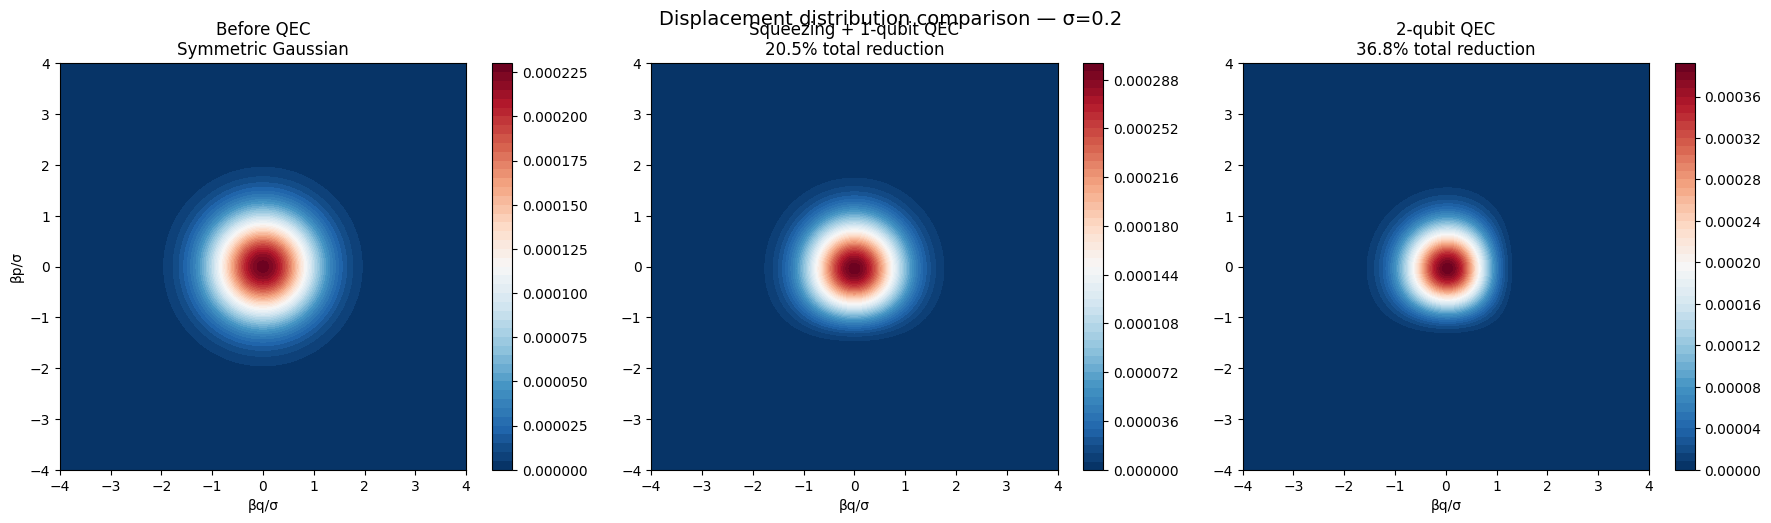

Before QEC     — Total Var = 0.040000
Squeezing QEC  — Total Var = 0.031797  reduction = 20.5%
2-qubit QEC    — Total Var = 0.025284  reduction = 36.8%


In [12]:
# Three panel comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Before QEC ───────────────────────────────
cont0 = axes[0].contourf(BQ/sigma, BP/sigma, P_before, levels=50, cmap='RdBu_r')
plt.colorbar(cont0, ax=axes[0])
axes[0].set_title('Before QEC\nSymmetric Gaussian')
axes[0].set_xlabel('βq/σ')
axes[0].set_ylabel('βp/σ')
axes[0].set_aspect('equal')

# ── Panel 2: Squeezing + 1-qubit QEC ─────────────────
# Recompute squeezing distribution on same grid
sigma_q = sigma * np.exp(2*zeta_opt)
sigma_p = sigma * np.exp(-2*zeta_opt)
alpha_opt_sq = 1 / (np.sqrt(8) * sigma_p)
beta_bar_sq  = 2 * alpha_opt_sq * sigma_p**2 * np.exp(-4 * alpha_opt_sq**2 * sigma_p**2)

P_squeezed = (G(BQ, sigma_q) *
              G(BP + beta_bar_sq, sigma_p) *
              (1 + np.sin(4 * alpha_opt_sq * (BP + beta_bar_sq))))
P_squeezed /= np.sum(P_squeezed)

cont1 = axes[1].contourf(BQ/sigma, BP/sigma, P_squeezed, levels=50, cmap='RdBu_r')
plt.colorbar(cont1, ax=axes[1])
axes[1].set_title('Squeezing + 1-qubit QEC\n20.5% total reduction')
axes[1].set_xlabel('βq/σ')
axes[1].set_aspect('equal')

# ── Panel 3: 2-qubit QEC ─────────────────────────────
cont2 = axes[2].contourf(BQ/sigma, BP/sigma, P_after_2qubit, levels=50, cmap='RdBu_r')
plt.colorbar(cont2, ax=axes[2])
axes[2].set_title('2-qubit QEC\n36.8% total reduction')
axes[2].set_xlabel('βq/σ')
axes[2].set_aspect('equal')

plt.suptitle(f'Displacement distribution comparison — σ={sigma}', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary
var_sq_q = np.sum(BQ**2 * P_squeezed)
var_sq_p = np.sum(BP**2 * P_squeezed)

print(f"Before QEC     — Total Var = {var_q_before+var_p_before:.6f}")
print(f"Squeezing QEC  — Total Var = {var_sq_q+var_sq_p:.6f}  reduction = {(1-(var_sq_q+var_sq_p)/(var_q_before+var_p_before))*100:.1f}%")
print(f"2-qubit QEC    — Total Var = {var_q_after+var_p_after:.6f}  reduction = {(1-(var_q_after+var_p_after)/(var_q_before+var_p_before))*100:.1f}%")